In [306]:
import pandas as pd

df = pd.read_csv('../datasets/redmi6.csv', encoding='windows-1252')

In [307]:
df.head()

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0 out of 5 stars,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0 out of 5 stars,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0 out of 5 stars,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0 out of 5 stars,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful


In [308]:
df['Rating'] = df['Rating'].str.split(' ', expand=True)[0]

In [309]:
df['Rating'].head()

0    4.0
1    3.0
2    3.0
3    5.0
4    2.0
Name: Rating, dtype: object

In [310]:
df

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
0,Another Midrange killer Smartphone by Xiaomi,Rishikumar Thakur,4.0,on 1 October 2018,Display,Another Midrange killer Smartphone by Xiaomi\n...,
1,vry small size mobile,Raza ji,3.0,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
2,Full display not working in all application.,Vaibhav Patel,3.0,on 18 September 2018,Others,Quite good,7 people found this helpful
3,Value for Money,Amazon Customer,5.0,on 28 September 2018,Display,Redmi has always have been the the king of bud...,2 people found this helpful
4,Not worth for the money,Sudhakaran Wadakkancheri,2.0,on 18 September 2018,Others,worst product from MI. I am a hardcore fan of ...,6 people found this helpful
...,...,...,...,...,...,...,...
275,"Cemera quality,face unlock most important in t...",Rahul,5.0,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
276,Mi is best phone,Sunil Soni,4.0,on 18 September 2018,Others,Product is avasome but invoice is note include...,NaN
277,Its a OK Phone,D.C.Padhi,3.0,on 15 September 2018,Battery,"Redmi Note4, Note5, now 6pro..It seems the old...",NaN
278,Redmi,Mahesh,5.0,on 21 September 2018,Others,I love mi,NaN


In [311]:
df = df[['Rating', 'Comments', 'Category']]

In [312]:
df.isnull().sum()

Rating      0
Comments    0
Category    0
dtype: int64

In [313]:
df

,Rating,Comments,Category
0,4.0,Another Midrange killer Smartphone by Xiaomi\n...,Display
1,3.0,All ok but vry small size mobile,Others
2,3.0,Quite good,Others
3,5.0,Redmi has always have been the the king of bud...,Display
4,2.0,worst product from MI. I am a hardcore fan of ...,Others
...,...,...,...
275,5.0,"I like This Phone, Awesome look and design.\nI...",Others
276,4.0,Product is avasome but invoice is note include...,Others
277,3.0,"Redmi Note4, Note5, now 6pro..It seems the old...",Battery
278,5.0,I love mi,Others


In [314]:
df.count()

Rating      280
Comments    280
Category    280
dtype: int64

In [315]:
import ollama


for i in range(len(df['Comments'])):
    comment = df['Comments'].iloc[i]

    response = ollama.generate(
        model='qwen2.5-coder:latest',  
        prompt=f"Categorize {comment}, make you return only: Very Negative, Negative, Neutral, Positive, Very Positive, without any explanation."
    )

    try:
        result = response['response'].strip()
        comment_category = 'Unknown'
        if result in ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']:
            comment_category = result
        else:
            comment_category = 'Unknown'
    except KeyError as e:
        print(f"KeyError: {e}") 

    df.loc[i,'Comment Categories'] = comment_category
    print(f"i: {i}, comment category: {comment_category}")

C:\Users\Han\AppData\Local\Temp\ipykernel_22708\2861435201.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[i,'Comment Categories'] = comment_category


i: 0, comment category: Positive
i: 1, comment category: Very Negative
i: 2, comment category: Positive
i: 3, comment category: Positive
i: 4, comment category: Negative
i: 5, comment category: Positive
i: 6, comment category: Positive
i: 7, comment category: Negative
i: 8, comment category: Neutral
i: 9, comment category: Negative
i: 10, comment category: Positive
i: 11, comment category: Negative
i: 12, comment category: Positive
i: 13, comment category: Positive
i: 14, comment category: Very Negative
i: 15, comment category: Positive
i: 16, comment category: Positive
i: 17, comment category: Negative
i: 18, comment category: Neutral
i: 19, comment category: Very Negative
i: 20, comment category: Positive
i: 21, comment category: Positive
i: 22, comment category: Negative
i: 23, comment category: Negative
i: 24, comment category: Positive
i: 25, comment category: Unknown
i: 26, comment category: Negative
i: 27, comment category: Negative
i: 28, comment category: Very Positive
i: 29, 

In [316]:
df['Comment Categories']

0           Positive
1      Very Negative
2           Positive
3           Positive
4           Negative
           ...      
275         Positive
276         Negative
277    Very Negative
278         Positive
279         Negative
Name: Comment Categories, Length: 280, dtype: object

In [317]:
df

,Rating,Comments,Category,Comment Categories
0,4.0,Another Midrange killer Smartphone by Xiaomi\n...,Display,Positive
1,3.0,All ok but vry small size mobile,Others,Very Negative
2,3.0,Quite good,Others,Positive
3,5.0,Redmi has always have been the the king of bud...,Display,Positive
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative
...,...,...,...,...
275,5.0,"I like This Phone, Awesome look and design.\nI...",Others,Positive
276,4.0,Product is avasome but invoice is note include...,Others,Negative
277,3.0,"Redmi Note4, Note5, now 6pro..It seems the old...",Battery,Very Negative
278,5.0,I love mi,Others,Positive


In [318]:
df['Comment Categories'].isnull().sum()

0

In [319]:
df = df[df['Comment Categories'].isin(['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])]

In [320]:
df

,Rating,Comments,Category,Comment Categories
0,4.0,Another Midrange killer Smartphone by Xiaomi\n...,Display,Positive
1,3.0,All ok but vry small size mobile,Others,Very Negative
2,3.0,Quite good,Others,Positive
3,5.0,Redmi has always have been the the king of bud...,Display,Positive
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative
...,...,...,...,...
275,5.0,"I like This Phone, Awesome look and design.\nI...",Others,Positive
276,4.0,Product is avasome but invoice is note include...,Others,Negative
277,3.0,"Redmi Note4, Note5, now 6pro..It seems the old...",Battery,Very Negative
278,5.0,I love mi,Others,Positive


In [321]:
df.count()

Rating                277
Comments              277
Category              277
Comment Categories    277
dtype: int64

In [322]:
df['Rating'] = df['Rating'].astype(float)

C:\Users\Han\AppData\Local\Temp\ipykernel_22708\229805355.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'] = df['Rating'].astype(float)


In [323]:
df['Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'}) 

C:\Users\Han\AppData\Local\Temp\ipykernel_22708\3368177604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'})


In [324]:
df.head() 

,Rating,Comments,Category,Comment Categories,Rating Categories
0,4.0,Another Midrange killer Smartphone by Xiaomi\n...,Display,Positive,Positive
1,3.0,All ok but vry small size mobile,Others,Very Negative,Neutral
2,3.0,Quite good,Others,Positive,Neutral
3,5.0,Redmi has always have been the the king of bud...,Display,Positive,Very Positive
4,2.0,worst product from MI. I am a hardcore fan of ...,Others,Negative,Negative


In [325]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

               Rating Categories Count  Comment Categories Count
Very Positive                      149                        12
Positive                            50                       146
Very Negative                       42                        25
Neutral                             27                        30
Negative                             9                        64


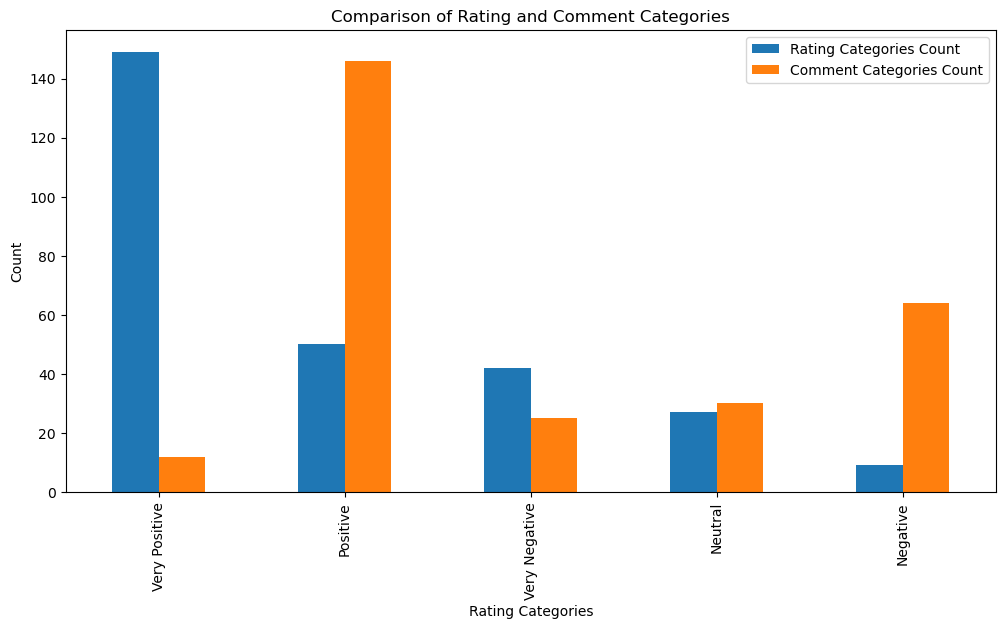

In [326]:
import matplotlib.pyplot as plt

# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [327]:
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 214


In [328]:
df['Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

C:\Users\Han\AppData\Local\Temp\ipykernel_22708\1479214151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'})


In [329]:
df['Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

C:\Users\Han\AppData\Local\Temp\ipykernel_22708\2795809008.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'})


In [330]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

          Rating Categories Count  Comment Categories Count
Positive                      199                       158
Negative                       51                        89
Neutral                        27                        30


In [331]:
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 82


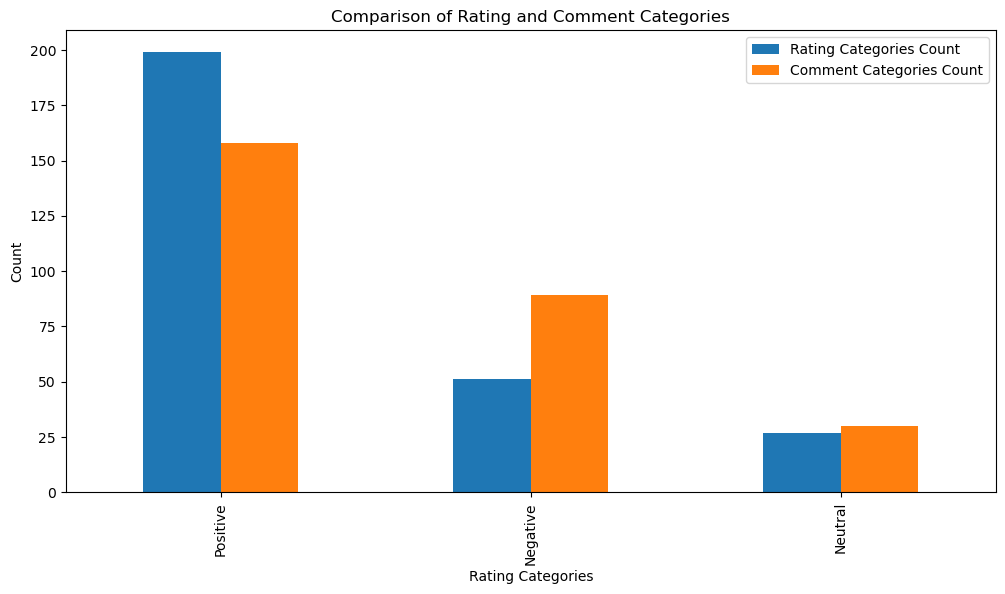

In [332]:
# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

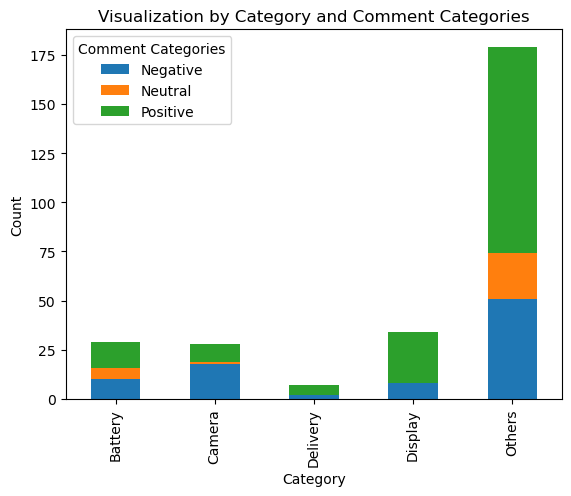

In [333]:
pivot_table = df.pivot_table(index='Category', columns='Comment Categories', aggfunc='size', fill_value=0)

# Display the pivot table
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Visualization by Category and Comment Categories')
plt.show()